# Phase 4: Advanced Hydraulic and Sediment Simulation

What You'll Learn:
- Understanding the Ansys interface, workflow, and applications in hydropower
- Preparing and importing project geometry
- Setting up computational domains and meshing strategies
- Fundamentals of simulating spillway flow and intake hydraulics

Practical Outcomes:
- Create an Ansys project from scratch
- Model ogee, labyrinth, and stepped spillways
- Simulate intake flow patterns and apply vortex suppression techniques
- Evaluate head loss and recommend design improvements

In [ ]:
# Reservoir and Discharge details
import math

# Design Parameters (Meters)
design_discharge = 4000.0 # Q (m^3/s) 
reservoir_normal_level = 500.0 # H (m) meters above mean sea level
downstream_water_level = 450.0 # H (m) meters above mean sea level
spillway_width = 50.0 # L (m)

# 1. Determine Design Head (Hd)
# Formula: Q = C * L * Hd^(1.5)
# Assuming Standard Ogee Spillway Discharge Coefficient (C) approx 2.0 - 2.2
discharge_coefficient = 2.2
design_head = math.pow(design_discharge / (discharge_coefficient * spillway_width), 2/3)

# 2. Determine Spillway Height (P)
# Assuming Spillway Crest is at Full Supply Level (Uncontrolled Spillway)
# Assuming River Bed is at Downstream Water Level (Simplified)
river_bed_elevation = downstream_water_level
spillway_crest_elevation = reservoir_normal_level
spillway_height = spillway_crest_elevation - river_bed_elevation

print(f"Design Head (Hd): {design_head:.2f} m")
print(f"Spillway Height (P): {spillway_height:.2f} m")

Design Head (Hd): 10.98 m
Spillway Height (P): 50.00 m


## Spillway Crest Equations (Reference: Spillway_Design.md)

### 1. Upstream Quadrant
The upstream face is defined by an ellipse:
$$ \frac{X^2}{A^2} + \frac{(B-Y)^2}{B^2} = 1 $$
Where:
- $A = 0.282 H_d$
- $B = 0.150 H_d$
- $H_d$ is the design head.

### 2. Downstream Quadrant (Ogee)
The downstream profile follows the WES standard equation:
$$ X^{1.85} = 2.0 H_d^{0.85} Y $$

### 3. Bottom Concave Curve (Bucket)
The transition from the spillway chute to the river bed is a circular arc (concave curve) with a radius $R$. This ensures smooth flow redirection and handles high pressures

Crest: (0, 500.00)
Ogee-Chute Tangent: (16.88, 487.84)
Chute-Bucket Tangent: (37.75, 460.00)
Toe (Bucket End): (57.75, 450.00)


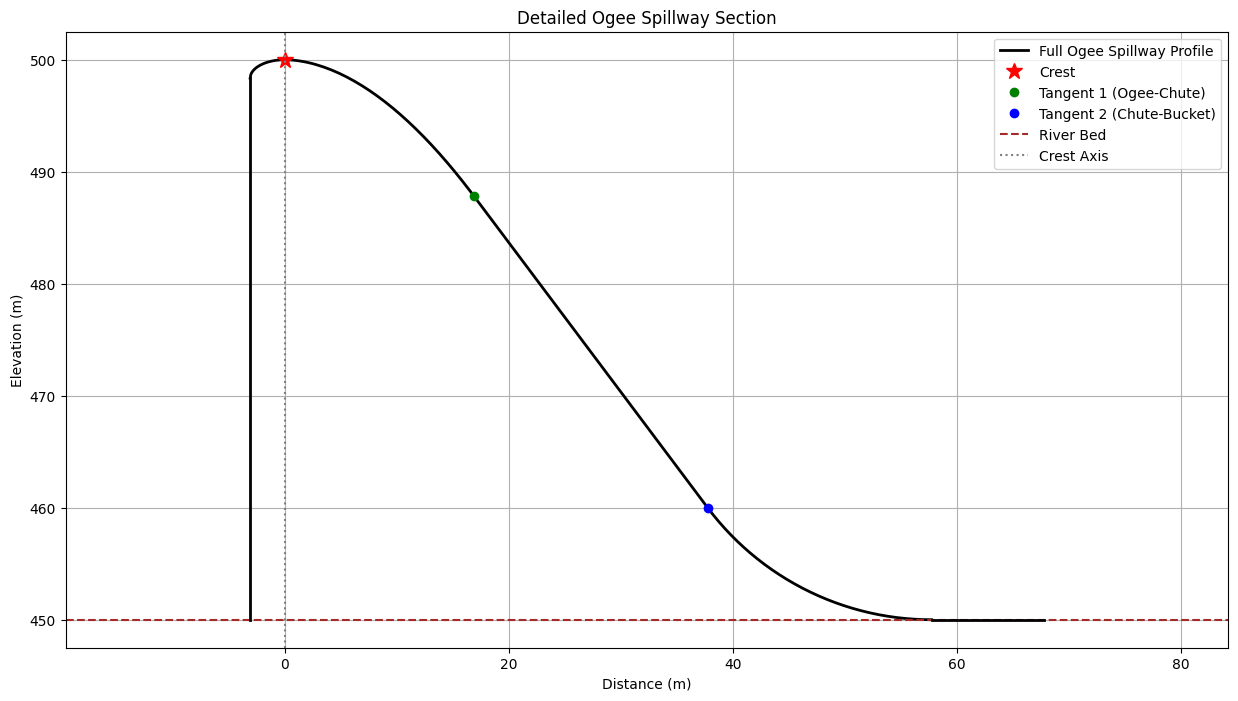

In [4]:
# Generate Detailed Spillway Geometry
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Parameters
Hd = design_head
P = spillway_height
R_bucket = P * 0.5  # Assumed Radius for Bottom Bucket (can be adjusted)
chute_slope_ratio = 0.75 # Horizontal run for 1 Vertical drop (1H:0.75V is not standard, usually 0.7H:1V). Let's use 1V:0.7H typical.
# Slope m = dy/dx. For 0.7H:1V, m = 1/0.7 = 1.428. 
# Since we plot Y negative down, slope is negative.
m_chute = -1.0 / 0.75  # Steep slope

# Elevations
crest_el = spillway_crest_elevation
bed_el = river_bed_elevation

# --- 1. Upstream Quadrant (Ellipse) ---
A = 0.282 * Hd
B = 0.150 * Hd
# X goes from -A to 0
x_us = np.linspace(-A, 0, 50)
# (X/A)^2 + ((B-Y)/B)^2 = 1  => (B-Y)/B = sqrt(1 - (X/A)^2) => Y = B - B*sqrt(1 - (X/A)^2)
# In our coord system, Y is negative downwards (elevation). 
# Standard equation Y is positive downwards. 
# Let's stick to: Crest at (0,0). Upstream face goes down. 
# Ellipse apex at (0,0). Vertical tangent at (-A, B_depth). 
# Y_coord = - (value from eq). 
y_us_local = - (B - B * np.sqrt(1 - (x_us/A)**2))
y_us = y_us_local + crest_el

# --- 2. Downstream Quadrant (Ogee) ---
K = 2.0 * np.power(Hd, 0.85)
# We need to find the point where Ogee slope equals m_chute
# Y = X^1.85 / K
# dy/dx = 1.85 * X^0.85 / K. (Note: this is positive Y down. So real slope in plot is negative of this)
# Plot Y = - X^1.85 / K.  Slope = -1.85 * X^0.85 / K
# Set Slope = m_chute => -1.85 * X^0.85 / K = m_chute
x_tan1 = np.power( (m_chute * K / -1.85), (1.0/0.85) )
y_tan1_local = - np.power(x_tan1, 1.85) / K
y_tan1 = y_tan1_local + crest_el

x_ogee = np.linspace(0, x_tan1, 50)
y_ogee_local = - np.power(x_ogee, 1.85) / K
y_ogee = y_ogee_local + crest_el

# --- 3. Bottom Concave Curve (Bucket) ---
# Circular arc tangent to chute slope m_chute and horizontal at bottom (slope 0).
# The bottom is at Y = -P (local) or bed_el (global).
# Circle center (Xc, Yc). Since tangent at bottom is horizontal, Yc = -P + R_bucket. Xc is unknown.
# Circle: (x - Xc)^2 + (y - Yc)^2 = R^2
# Tangent at some point (xt, yt) with slope m_chute.
# Normal vector at (xt, yt) has slope -1/m_chute.
# Angle of chute from horizontal: alpha = arctan(abs(m_chute)).
# The arc spans angle alpha.
# xt = Xc - R * sin(alpha)
# yt = Yc - R * cos(alpha)  (Check quadrants: Center is above and right of tangent point for concave up transition?)
# Wait, chute comes down (neg slope). Bucket curves up to horizontal.
# Center is Up and Right relative to the curve. 
# Yc = -P + R_bucket. (Center is above bed).
# At tangent point T2 (end of straight chute),
# dy/dx = m_chute.
# Geometry: Change in Y from T2 to Bottom = R * (1 - cos(alpha)).
# Change in X from T2 to Bottom = R * sin(alpha).
alpha = np.arctan(abs(m_chute))
dy_bucket = R_bucket * (1 - np.cos(alpha))
dx_bucket = R_bucket * np.sin(alpha)

y_tan2_local = -P + dy_bucket  # Y elevation of T2 (start of bucket)
y_tan2 = y_tan2_local + crest_el
x_tan2_local = dx_bucket # X distance from bottom-tangent to T2

# --- 4. Straight Chute ---
# Connects (x_tan1, y_tan1) to (x_tan2_global, y_tan2)
# We know y_tan1 and y_tan2. We know slope m_chute.
# y_tan2 - y_tan1 = m_chute * (x_tan2_global - x_tan1)
x_tan2_global = x_tan1 + (y_tan2 - y_tan1) / m_chute

# Verify Geometry feasibility
if y_tan2 > y_tan1:
    print("Warning: Spillway height insufficient for full chute development with given parameters.")
    # Fallback or adjust? For now proceed.

x_chute = np.linspace(x_tan1, x_tan2_global, 20)
y_chute = y_tan1 + m_chute * (x_chute - x_tan1)

# --- Generate Bucket Points ---
# Center (Xc, Yc)
Xc = x_tan2_global + dx_bucket # Wait, if T2 is at x_tan2_global, and bottom is further downstream.
Yc_local = -P + R_bucket
Yc = Yc_local + crest_el
# Angles from (alpha + 3pi/2) to (3pi/2)? 
# Vector from Center to T2: Angle = 270 deg - alpha? Or 180+...
# Slope of radius to T2 is -1/m_chute (perp to tangent).
# Angle range: From tangent angle to bottom (270 deg / -90 deg).
# Start angle (at T2): theta_start = 1.5*pi + alpha ?
# Let's use angles relative to center.
# Bottom point: Angle -90 (3pi/2). (Xc, Yc-R)
# T2: Angle ? x = Xc - R sin(alpha), y = Yc - R cos(alpha). 
# Check slope: -(x-Xc)/(y-Yc) = -(-sin)/(-cos) = -tan. Tangent slope? -cot? 
# dy/dx of circle = -(x-Xc)/(y-Yc).
# At T2: -( -R sin ) / ( -R cos ) = - tan(alpha). 
# Slope m_chute is negative. tan(alpha) is positive (abs). So -tan(alpha) is correct slope. 
# Correct.
# theta goes from (270 deg - alpha_deg) to 270 deg.
theta_start = 1.5 * np.pi - alpha
theta_end = 1.5 * np.pi
thetas = np.linspace(theta_start, theta_end, 30)

x_bucket = Xc + R_bucket * np.cos(thetas)
y_bucket = Yc + R_bucket * np.sin(thetas)

# Concatenate All Points
x_final = np.concatenate([x_us, x_ogee[1:], x_chute[1:], x_bucket[1:]])
y_final = np.concatenate([y_us, y_ogee[1:], y_chute[1:], y_bucket[1:]])

print(f"Crest: (0, {crest_el:.2f})")
print(f"Ogee-Chute Tangent: ({x_tan1:.2f}, {y_tan1:.2f})")
print(f"Chute-Bucket Tangent: ({x_tan2_global:.2f}, {y_tan2:.2f})")
print(f"Toe (Bucket End): ({x_bucket[-1]:.2f}, {y_bucket[-1]:.2f})")

# Plotting
plt.figure(figsize=(15, 8))
plt.plot(x_final, y_final, label='Full Ogee Spillway Profile', linewidth=2, color='black')
plt.plot([0], [crest_el], 'r*', markersize=12, label='Crest')
plt.plot([x_tan1], [y_tan1], 'go', label='Tangent 1 (Ogee-Chute)')
plt.plot([x_tan2_global], [y_tan2], 'bo', label='Tangent 2 (Chute-Bucket)')

plt.axhline(bed_el, color='brown', linestyle='--', label='River Bed')
plt.axvline(0, color='gray', linestyle=':', label='Crest Axis')

# Upstream vertical face
plt.plot([-A, -A], [y_us[0], bed_el], color='black', linewidth=2)
plt.plot([x_bucket[-1], x_bucket[-1]+10], [bed_el, bed_el], color='black', linewidth=2) # River bed extension

plt.title('Detailed Ogee Spillway Section')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
# Display Coordinates for Manual Drawing
print(f"{'Description':<30} | {'X (m)':>10} | {'Y (m)':>10}")
print("-" * 56)

# 1. Upstream Curve (2 coordinates)
idx_us = [0, 25]
pts_us = list(zip(x_us[idx_us], y_us[idx_us]))
labels_us = ['Upstream Start', 'Upstream Mid']

# 2. Crest Coordinate
pts_crest = [(0, crest_el)]
labels_crest = ['Crest']

# 3. Parabolic Curve (5 coordinates)
idx_ogee = np.linspace(1, len(x_ogee)-1, 5, dtype=int)
pts_ogee = list(zip(x_ogee[idx_ogee], y_ogee[idx_ogee]))
labels_ogee = [f'Parabolic {i+1}' for i in range(5)]

# 4. Tangent (2 coordinates)
pts_tangent = [(x_tan1, y_tan1), (x_tan2_global, y_tan2)]
labels_tangent = ['Tangent Start', 'Tangent End']

# 5. Bottom Circular Curve (3 cordinates)
idx_bucket = np.linspace(0, len(x_bucket)-1, 3, dtype=int)
pts_bucket = list(zip(x_bucket[idx_bucket], y_bucket[idx_bucket]))
labels_bucket = ['Bucket Start', 'Bucket Mid', 'Bucket End (Toe)']

# 6. One more point at the end
pts_end = [(x_bucket[-1] + 10, bed_el)]
labels_end = ['River Bed Extension']

# Combine
all_pts = pts_us + pts_crest + pts_ogee + pts_tangent + pts_bucket + pts_end
all_labels = labels_us + labels_crest + labels_ogee + labels_tangent + labels_bucket + labels_end

for desc, (x, y) in zip(all_labels, all_pts):
    print(f"{desc:<30} | {x:10.2f} | {y:10.2f}")

Description                    |      X (m) |      Y (m)
--------------------------------------------------------
Upstream Start                 |      -3.10 |     498.35
Upstream Mid                   |      -1.52 |     499.79
Crest                          |       0.00 |     500.00
Parabolic 1                    |       0.34 |     499.99
Parabolic 2                    |       4.48 |     498.96
Parabolic 3                    |       8.61 |     496.50
Parabolic 4                    |      12.74 |     492.77
Parabolic 5                    |      16.88 |     487.84
Tangent Start                  |      16.88 |     487.84
Tangent End                    |      37.75 |     460.00
Bucket Start                   |      37.75 |     460.00
Bucket Mid                     |      46.22 |     452.82
Bucket End (Toe)               |      57.75 |     450.00
River Bed Extension            |      67.75 |     450.00


In [6]:
# Draw Closed Ogee Spillway Section in AutoCAD
try:
    from myAutoCAD import myAutoCAD
    import array

    # Connect to AutoCAD
    acad = myAutoCAD()

    # Prepare points for LightWeightPolyline (2D flat polyline)
    # Format: [x1, y1, x2, y2, ...]
    poly_points = []

    # 1. Ogee Curve Points (Upstream to Toe)
    # x_final and y_final contain the entire profile from upstream (X=-A) to toe (X=X_toe)
    for x, y in zip(x_final, y_final):
        poly_points.append(float(x))
        poly_points.append(float(y))

    # 2. Base/Heel Point (Bottom Left)
    # The profile ends at the Toe on the River Bed. 
    # We need to draw back to the Heel (-A, river_bed_elevation) to close the section.
    # Assuming river_bed_elevation is available as bed_el from previous cell or variable.
    # Safe bet: use y_final[-1] which is at bed elevation, so use that Y for the heel point (-A).
    bed_elevation = y_final[-1]
    poly_points.append(-float(A))
    poly_points.append(float(bed_elevation))

    # 3. Closure
    # The Polyline will close back to the first point (-A, B_us_start) automatically.
    
    # Create array of doubles for AutoCAD COM interface
    points_array = array.array('d', poly_points)

    # Add LightWeightPolyline to Model Space
    pline = acad.model.AddLightWeightPolyline(points_array)
    pline.Closed = True
    pline.Update()

    print(f"Successfully drew Closed Ogee Spillway Section in AutoCAD.")
    print(f"Layer: {pline.Layer}, Handle: {pline.Handle}")

except ImportError:
    print("Error: 'myAutoCAD' module not found. Please ensure myAutoCAD.py is in the notebook directory.")
except Exception as e:
    print(f"An error occurred communicating with AutoCAD: {e}")

Connecting to AutoCAD...
Connected to: spillway.dwg
Successfully drew Closed Ogee Spillway Section in AutoCAD.
Layer: 0, Handle: 711C
